In [1]:
%pip install -q segmentation-models-pytorch albumentations opencv-python timm huggingface_hub matplotlib Pillow pandas


In [2]:
import os, sys, json, time, random, hashlib, platform, subprocess
import datetime as dt
from pathlib import Path
from importlib import metadata as importlib_metadata
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

SEED = 42
METHOD_NAME = "UNetPP_EfficientNetV2"
ENCODER = "tu-efficientnetv2_rw_m"
THRESHOLD = 0.5
PAD_MULTIPLE = 32
# Sửa: Chiều cao H = 1654, Chiều rộng W = 1170
TARGET_HEIGHT, TARGET_WIDTH = 1654, 1170
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
RAW_ZIP = "/content/drive/MyDrive/DIP/data/raw/Manga109s_released_2026_05_21-001.zip"
RAW_EXTRACT_ROOT = Path("/content/data/raw")
RAW_DIR = RAW_EXTRACT_ROOT / "Manga109s_released_2026_05_21" / "images"
PROJECT_PAGE_LIST_PATH = Path("/content/project_page_list.json")
DELIVERABLE_ROOT = Path("/content/deliverables") / METHOD_NAME
MASK_DIR = DELIVERABLE_ROOT / "masks"
METADATA_DIR = DELIVERABLE_ROOT / "metadata"
FIG_DIR = DELIVERABLE_ROOT / "visualizations"
for p in [DELIVERABLE_ROOT, MASK_DIR, METADATA_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
RUN_TIMESTAMP = dt.datetime.now(dt.timezone.utc).isoformat()
print("Method:", METHOD_NAME); print("Device:", DEVICE); print("GPU:", GPU_NAME)

Method: UNetPP_EfficientNetV2
Device: cuda
GPU: Tesla T4


In [3]:
from google.colab import drive
drive.mount("/content/drive")

RAW_EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
if not Path(RAW_ZIP).exists():
    raise FileNotFoundError(RAW_ZIP)

print("Extracting RAW...")
!unzip -q -o "/content/drive/MyDrive/DIP/data/raw/Manga109s_released_2026_05_21-001.zip" -d "/content/data/raw"
if not RAW_DIR.exists():
    candidates = list(RAW_EXTRACT_ROOT.rglob("images"))
    if len(candidates) == 1:
        RAW_DIR = candidates[0]
if not RAW_DIR.exists():
    raise FileNotFoundError(RAW_DIR)
print("RAW_DIR:", RAW_DIR)

# Thiết lập đường dẫn Ground-truth để đối chiếu danh sách (chỉ đọc tên file, không nạp pixel vào model)
GT_ZIP = "/content/drive/MyDrive/DIP/data/groundtruth/post-processed.zip"
GT_DIR = Path("/content/data/groundtruth/post-processed")

if Path(GT_ZIP).exists() and not GT_DIR.exists():
    print("Extracting Ground-truth metadata...")
    GT_DIR.mkdir(parents=True, exist_ok=True)
    !unzip -q -o "{GT_ZIP}" -d "/content/data/groundtruth"

print("GT_DIR:", GT_DIR if GT_DIR.exists() else "Not found, will check folder structure")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting RAW...
RAW_DIR: /content/data/raw/Manga109s_released_2026_05_21/images
Extracting Ground-truth metadata...
GT_DIR: /content/data/groundtruth/post-processed


In [6]:
REPO_DIR=Path("/content/Manga-Text-Segmentation")
if not REPO_DIR.exists():
    !git clone https://github.com/ContemporaryCat/Manga-Text-Segmentation.git /content/Manga-Text-Segmentation

def git(*args):
    r=subprocess.run(["git","-C",str(REPO_DIR),*args],capture_output=True,text=True,check=False)
    return r.stdout.strip()
REPOSITORY=git("config","--get","remote.origin.url")
COMMIT=git("rev-parse","HEAD")
GIT_DIRTY=bool(git("status","--porcelain"))
license_files=list(REPO_DIR.glob("LICENSE*"))
CODE_LICENSE=license_files[0].read_text(encoding="utf-8",errors="replace")[:4000] if license_files else "NOT_STATED_BY_UPSTREAM_REPOSITORY"
print("Repository:",REPOSITORY); print("Commit:",COMMIT); print("Dirty:",GIT_DIRTY)


Repository: https://github.com/ContemporaryCat/Manga-Text-Segmentation.git
Commit: 6cfa907b0721faa398054be527de98171746ef1b
Dirty: False


In [7]:
from huggingface_hub import hf_hub_download
MODEL_PATH=Path(hf_hub_download(repo_id="a-b-c-x-y-z/Manga-Text-Segmentation-2025",filename="model.pth",local_dir=str(REPO_DIR)))
print("Checkpoint:",MODEL_PATH); print("Size MB:",round(MODEL_PATH.stat().st_size/(1024**2),2))


model.pth: reconstructing file:   0%|          |  0.00B /  217MB            

model.pth: downloading bytes:           |  0.00B            

Checkpoint: /content/Manga-Text-Segmentation/model.pth
Size MB: 206.86


In [8]:
import torch.nn as nn

# 1. Khởi tạo model đúng cấu trúc gốc có BatchNorm
model = smp.UnetPlusPlus(
    encoder_name=ENCODER,
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None,
    decoder_attention_type="scse"
)

# 2. Tắt track_running_stats ở decoder để khớp với checkpoint không lưu running stats
for m in model.decoder.modules():
    if isinstance(m, (nn.BatchNorm2d, nn.SyncBatchNorm)):
        m.track_running_stats = False
        m.running_mean = None
        m.running_var = None
        m.num_batches_tracked = None

# 3. Nạp state_dict
checkpoint = torch.load(str(MODEL_PATH), map_location=DEVICE)
state_dict = checkpoint["state_dict"] if isinstance(checkpoint, dict) and "state_dict" in checkpoint else checkpoint
state_dict = {(k[7:] if k.startswith("module.") else k): v for k, v in state_dict.items()}

# Nạp strict=True để đảm bảo 100% khớp key và shape
model.load_state_dict(state_dict, strict=True)
model = model.to(DEVICE).eval()
print("Model loaded successfully with strict=True!")

Model loaded successfully with strict=True!


In [9]:
def sha256_file(path, chunk_size=1<<20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b: break
            h.update(b)
    return h.hexdigest()

def sha256_bytes(data):
    return hashlib.sha256(data).hexdigest()

CKPT_SHA256 = sha256_file(MODEL_PATH)
CKPT_SIZE_BYTES = MODEL_PATH.stat().st_size
msd = model.state_dict()

missing = sorted(set(state_dict.keys()) - set(msd.keys()))
unexpected = sorted(set(msd.keys()) - set(state_dict.keys()))

checked = exact = 0
for k, v in state_dict.items():
    if k in msd:
        checked += 1
        if torch.equal(msd[k].detach().cpu().float(), v.detach().cpu().float()):
            exact += 1

strict_load_ok = (len(missing) == 0 and len(unexpected) == 0 and checked == exact)

fp = hashlib.sha256()
for k in sorted(msd):
    fp.update(k.encode())
    fp.update(msd[k].detach().cpu().float().numpy().tobytes())
PARAM_FINGERPRINT = fp.hexdigest()

with torch.no_grad():
    g = torch.Generator().manual_seed(SEED)
    probe = torch.randn(1, 3, 64, 64, generator=g).to(DEVICE)
    probe_out = model(probe).float().cpu().numpy()
PROBE_CHECKSUM = sha256_bytes(np.ascontiguousarray(probe_out).tobytes())

CHECKPOINT_INFO = {
    "name": MODEL_PATH.name,
    "source": "huggingface:a-b-c-x-y-z/Manga-Text-Segmentation-2025/model.pth",
    "size_bytes": CKPT_SIZE_BYTES,
    "sha256": CKPT_SHA256,
    "loaded_evidence": {
        "strict_load_ok": strict_load_ok,
        "checkpoint_state_dict_keys": len(state_dict),
        "model_state_dict_keys": len(msd),
        "keys_compared": checked,
        "keys_bitwise_identical": exact,
        "missing_keys": missing,
        "unexpected_keys": unexpected,
        "loaded_param_fingerprint_sha256": PARAM_FINGERPRINT,
        "fixed_probe_output_sha256": PROBE_CHECKSUM
    },
    "weight_license": "NOT_VERIFIED__VERIFY_HUGGING_FACE_MODEL_CARD"
}

assert strict_load_ok, f"Trọng số không khớp: missing={missing}, unexpected={unexpected}, checked={checked}, exact={exact}"
print("Checkpoint SHA256:", CKPT_SHA256)
print("Positive loading evidence verified (strict=True):", strict_load_ok)

Checkpoint SHA256: a0a895dc385608554a81ca765b0c62d654462c2bac661abdff63634985ab37fc
Positive loading evidence verified (strict=True): True


In [10]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def discover_pages_from_groundtruth(raw_dir, gt_dir):
    pages = []
    # Quét tất cả các file mask trong ground-truth (dạng <manga>/<page_id>.png)
    gt_masks = sorted(list(gt_dir.rglob("*.png")))

    for mask_path in gt_masks:
        rel = mask_path.relative_to(gt_dir)
        if len(rel.parts) >= 2:
            manga = rel.parts[0]
            page_id = mask_path.stem

            # Tìm file ảnh gốc tương ứng trong raw_dir (thường là .jpg hoặc .png)
            raw_candidates = [
                raw_dir / manga / f"{page_id}{ext}"
                for ext in [".jpg", ".png", ".jpeg", ".webp"]
            ]

            matched_raw = None
            for c in raw_candidates:
                if c.exists():
                    matched_raw = c
                    break

            if matched_raw:
                pages.append({
                    "image_id": f"{manga}/{page_id}",
                    "manga": manga,
                    "page_id": page_id,
                    "image_path": str(matched_raw)
                })

    return sorted(pages, key=lambda r: r["image_id"])

# Kiểm tra nếu có file project_page_list.json từ project
if PROJECT_PAGE_LIST_PATH.exists():
    artifact = json.loads(PROJECT_PAGE_LIST_PATH.read_text(encoding="utf-8"))
    page_list = artifact["pages"] if isinstance(artifact, dict) else artifact
    PAGE_LIST_IDENTITY = artifact.get("page_list_identity") if isinstance(artifact, dict) else None
    PROJECT_INPUT_IDENTITY = artifact.get("input_image_identity") if isinstance(artifact, dict) else None
    PAGE_LIST_SOURCE = "project-issued"
elif GT_DIR.exists():
    page_list = discover_pages_from_groundtruth(RAW_DIR, GT_DIR)
    PAGE_LIST_IDENTITY = "DERIVED_FROM_LOCAL_GROUNDTRUTH"
    PROJECT_INPUT_IDENTITY = None
    PAGE_LIST_SOURCE = "ground-truth name-matched discovery"
else:
    raise FileNotFoundError(f"Không tìm thấy thư mục Ground-truth tại {GT_DIR} để lọc danh sách.")

print("Page-list source:", PAGE_LIST_SOURCE)
print("Page count:", len(page_list)) # Sẽ ra đúng khoảng 390-450 trang thay vì 8519
assert len(page_list) > 0, "Không tìm thấy trang nào khớp giữa RAW và Ground-truth!"

Page-list source: ground-truth name-matched discovery
Page count: 390


In [11]:
image_sha={}
for i,rec in enumerate(page_list,1):
    p=Path(rec["image_path"])
    if not p.exists(): raise FileNotFoundError(f"Missing input: {rec['image_id']} -> {p}")
    image_sha[rec["image_id"]]=sha256_file(p)
    if i%50==0 or i==len(page_list): print(f"Hashed {i}/{len(page_list)}")


Hashed 50/390
Hashed 100/390
Hashed 150/390
Hashed 200/390
Hashed 250/390
Hashed 300/390
Hashed 350/390
Hashed 390/390


In [12]:
TARGET_HEIGHT, TARGET_WIDTH = 1170, 1654

transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

def load_and_align(path):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise IOError(f"cv2.imread failed: {path}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    h, w = rgb.shape[:2]
    if h < TARGET_HEIGHT or w < TARGET_WIDTH:
        raise ValueError(f"Input {w}x{h} smaller than required {TARGET_WIDTH}x{TARGET_HEIGHT}")
    # Cắt top-left về đúng chuẩn 1170x1654 (Height x Width)
    return rgb, rgb[:TARGET_HEIGHT, :TARGET_WIDTH]

def predict(aligned):
    t = time.perf_counter()
    tensor = transform(image=aligned)["image"].unsqueeze(0).to(DEVICE)
    ph = (PAD_MULTIPLE - TARGET_HEIGHT % PAD_MULTIPLE) % PAD_MULTIPLE
    pw = (PAD_MULTIPLE - TARGET_WIDTH % PAD_MULTIPLE) % PAD_MULTIPLE
    if ph or pw:
        tensor = F.pad(tensor, (0, pw, 0, ph), mode="constant", value=0)
    pre = time.perf_counter() - t

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    t = time.perf_counter()
    with torch.no_grad():
        if DEVICE.type == "cuda":
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                logits = model(tensor)
        else:
            logits = model(tensor)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    inf = time.perf_counter() - t

    t = time.perf_counter()
    prob = torch.sigmoid(logits)[0, 0, :TARGET_HEIGHT, :TARGET_WIDTH].float().cpu().numpy()
    mask = (prob >= THRESHOLD).astype(np.uint8) * 255
    assert mask.shape == (TARGET_HEIGHT, TARGET_WIDTH) and mask.dtype == np.uint8 and set(np.unique(mask)).issubset({0, 255})
    post = time.perf_counter() - t
    return mask, pre, inf, post

In [13]:
# Smoke test: first 1-2 raw pages only; no GT.
smoke = []
for rec in page_list[:min(2, len(page_list))]:
    _, aligned = load_and_align(rec["image_path"])
    mask, a, b, c = predict(aligned)
    smoke.append({
        "image_id": rec["image_id"],
        "shape": list(mask.shape),
        "dtype": str(mask.dtype),
        "unique": np.unique(mask).tolist(),
        "inference": b
    })
print(json.dumps(smoke, indent=2))
print("Smoke test PASS")

[
  {
    "image_id": "ARMS/000",
    "shape": [
      1170,
      1654
    ],
    "dtype": "uint8",
    "unique": [
      0,
      255
    ],
    "inference": 4.0090771889999814
  },
  {
    "image_id": "ARMS/001",
    "shape": [
      1170,
      1654
    ],
    "dtype": "uint8",
    "unique": [
      0,
      255
    ],
    "inference": 0.25590914799977327
  }
]
Smoke test PASS


In [14]:
def package_versions(names):
    out={}
    for n in names:
        try: out[n]=importlib_metadata.version(n)
        except Exception: out[n]=None
    return out
PACKAGES=package_versions(["torch","torchvision","numpy","opencv-python","albumentations","segmentation-models-pytorch","timm","huggingface-hub","Pillow","matplotlib","pandas","scipy"])
ENVIRONMENT={"python_version":sys.version.split()[0],"python_full":sys.version,"platform":platform.platform(),"packages":PACKAGES,"torch_version":torch.__version__,"cuda_version":torch.version.cuda,"cudnn_version":torch.backends.cudnn.version() if torch.cuda.is_available() else None,"device":{"type":DEVICE.type,"name":GPU_NAME,"index":0 if torch.cuda.is_available() else None,"capability":list(torch.cuda.get_device_capability(0)) if torch.cuda.is_available() else None}}
print(json.dumps(ENVIRONMENT,indent=2,ensure_ascii=False))


{
  "python_version": "3.13.15",
  "python_full": "3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
  "packages": {
    "torch": "2.11.0+cu128",
    "torchvision": "0.26.0+cu128",
    "numpy": "2.1.3",
    "opencv-python": "5.0.0.93",
    "albumentations": "2.0.8",
    "segmentation-models-pytorch": "0.5.0",
    "timm": "1.0.29",
    "huggingface-hub": "1.29.0",
    "Pillow": "11.3.0",
    "matplotlib": "3.10.0",
    "pandas": "2.2.3",
    "scipy": "1.16.3"
  },
  "torch_version": "2.11.0+cu128",
  "cuda_version": "12.8",
  "cudnn_version": 91900,
  "device": {
    "type": "cuda",
    "name": "Tesla T4",
    "index": 0,
    "capability": [
      7,
      5
    ]
  }
}


In [15]:
errors = []; manifest = []; start = time.perf_counter()
for idx, rec in enumerate(page_list, 1):
    image_id = rec["image_id"]
    manga = rec["manga"]
    page_id = rec["page_id"]
    mp = MASK_DIR / manga / f"{page_id}.png"
    jp = METADATA_DIR / manga / f"{page_id}.json"
    mp.parent.mkdir(parents=True, exist_ok=True)
    jp.parent.mkdir(parents=True, exist_ok=True)

    status = "success"
    err = None
    nh = nw = None
    pre = inf = post = 0.0
    msha = None
    text_pixels = None
    coverage = None

    try:
        native, aligned = load_and_align(rec["image_path"])
        nh, nw = native.shape[:2]
        mask, pre, inf, post = predict(aligned)
        is_success, buf = cv2.imencode(".png", mask)
        if not is_success:
            raise IOError(f"cv2.imencode failed for {mp}")
        with open(mp, "wb") as f:
            f.write(buf)
        msha = sha256_file(mp)
        text_pixels = int(np.count_nonzero(mask == 255))
        coverage = text_pixels / float(TARGET_HEIGHT * TARGET_WIDTH)
    except Exception as e:
        status = "failed"
        err = {"type": type(e).__name__, "message": str(e)}
        errors.append({"image_id": image_id, "manga": manga, "page_id": page_id, "stage": "runner", "error": err, "timestamp": dt.datetime.now(dt.timezone.utc).isoformat()})
        print(f"[ERROR {idx}/{len(page_list)}] {image_id}: {e}")

    # Metadata sidecar đúng contract chuẩn của ONBOARDING.md
    side = {
        "image_id": image_id,
        "page_list_identity": PAGE_LIST_IDENTITY if PAGE_LIST_IDENTITY else "EXPLORATORY_NO_IDENTITY",
        "input_image_identity": PROJECT_INPUT_IDENTITY if PROJECT_INPUT_IDENTITY else image_sha[image_id],
        "method": METHOD_NAME,
        "repository": REPOSITORY,
        "commit": COMMIT,
        "code_license": CODE_LICENSE,
        "checkpoint": CHECKPOINT_INFO,
        "input_size": [TARGET_HEIGHT, TARGET_WIDTH],
        "output_size": [TARGET_HEIGHT, TARGET_WIDTH],
        "preprocessing": ["crop-topleft-1654x1170", "ImageNet-norm", f"pad-multiple-{PAD_MULTIPLE}"],
        "postprocessing": [f"sigmoid-threshold-{THRESHOLD}"],
        "threshold": THRESHOLD,
        "alignment": "spec-001-aligned-space",
        "device": {"type": DEVICE.type, "name": GPU_NAME},
        "interpreter": sys.version.split()[0],
        "packages": PACKAGES,
        "seed": SEED,
        "run_timestamp": RUN_TIMESTAMP,
        "inference_time_seconds": inf,
        "preprocessing_time_seconds": pre,
        "postprocessing_time_seconds": post,
        "status": status,
        "error": err
    }
    jp.write_text(json.dumps(side, indent=2, ensure_ascii=False), encoding="utf-8")
    manifest.append({"image_id": image_id, "status": status, "mask": str(mp.relative_to(DELIVERABLE_ROOT)) if status == "success" else None, "metadata": str(jp.relative_to(DELIVERABLE_ROOT)), "coverage": coverage, "inference_time_seconds": inf})
    if idx % 25 == 0 or idx == len(page_list):
        print(f"[{idx:>4}/{len(page_list)}] {image_id} | {status} | inf={inf:.3f}s")

total_time = time.perf_counter() - start
print("RUN COMPLETE:", len(page_list), "pages;", sum(x["status"] == "success" for x in manifest), "SUCCESS;", sum(x["status"] != "success" for x in manifest), "failed")

[  25/390] AkkeraKanjinchou/004 | success | inf=0.257s
[  50/390] AosugiruHaru/009 | success | inf=0.257s
[  75/390] BEMADER_P/004 | success | inf=0.258s
[ 100/390] BurariTessenTorimonocho/009 | success | inf=0.260s
[ 125/390] Donburakokko/004 | success | inf=0.259s
[ 150/390] EienNoWith/009 | success | inf=0.260s
[ 175/390] GakuenNoise/004 | success | inf=0.260s
[ 200/390] GinNoChimera/009 | success | inf=0.261s
[ 225/390] HaruichibanNoFukukoro/004 | success | inf=0.261s
[ 250/390] HealingPlanet/009 | success | inf=0.263s
[ 275/390] TsubasaNoKioku/004 | success | inf=0.264s
[ 300/390] UchuKigekiM774/009 | success | inf=0.261s
[ 325/390] WarewareHaOniDearu/004 | success | inf=0.264s
[ 350/390] YasasiiAkuma/009 | success | inf=0.265s
[ 375/390] YumeNoKayoiji/004 | success | inf=0.267s
[ 390/390] YumeiroCooking/009 | success | inf=0.267s
RUN COMPLETE: 390 pages; 390 SUCCESS; 0 failed


In [16]:
(DELIVERABLE_ROOT/"errors.json").write_text(json.dumps({"method":METHOD_NAME,"run_timestamp":RUN_TIMESTAMP,"page_list_source":PAGE_LIST_SOURCE,"page_count":len(page_list),"error_count":len(errors),"errors":errors},indent=2,ensure_ascii=False),encoding="utf-8")
print("Created errors.json")


Created errors.json


In [17]:
# Visualizations: original + prediction + prediction overlay. No GT.
ok=[m for m in manifest if m["status"]=="ok" and m["coverage"] is not None]
ok.sort(key=lambda x:x["coverage"])
if ok:
    n=min(3,len(ok)); groups={"low_prediction_coverage":ok[:n],"median_prediction_coverage":ok[max(0,len(ok)//2-n//2):][:n],"high_prediction_coverage":ok[-n:]}; lookup={r["image_id"]:r for r in page_list}
    for group,items in groups.items():
        for item in items:
            rec=lookup[item["image_id"]]; _,aligned=load_and_align(rec["image_path"]); mask=cv2.imread(str(DELIVERABLE_ROOT/item["mask"]),cv2.IMREAD_GRAYSCALE)
            overlay=aligned.copy(); overlay[mask==255]=(0.35*overlay[mask==255]+0.65*np.array([255,0,0],dtype=np.float32)).astype(np.uint8)
            fig,ax=plt.subplots(1,3,figsize=(16,6)); ax[0].imshow(aligned); ax[0].set_title("Aligned Original"); ax[1].imshow(mask,cmap="gray"); ax[1].set_title("Prediction"); ax[2].imshow(overlay); ax[2].set_title("Prediction Overlay")
            for a in ax: a.axis("off")
            fig.suptitle(f"{item['image_id']} | {group} | coverage={item['coverage']:.4f}"); fig.tight_layout()
            out=FIG_DIR/group/f"{item['image_id'].replace('/','__')}.png"; out.parent.mkdir(parents=True,exist_ok=True); fig.savefig(out,dpi=110,bbox_inches="tight"); plt.close(fig)
print("Visualizations created:",FIG_DIR)


Visualizations created: /content/deliverables/UNetPP_EfficientNetV2/visualizations


In [18]:
required=["torch","torchvision","numpy","opencv-python","albumentations","segmentation-models-pytorch","timm","huggingface-hub","Pillow","matplotlib","pandas"]
(DELIVERABLE_ROOT/"requirements.txt").write_text("\n".join([f"{n}=={PACKAGES[n]}" if PACKAGES.get(n) else n for n in required])+"\n",encoding="utf-8")


225

In [19]:
admissible=bool(PAGE_LIST_SOURCE=="project-issued" and PAGE_LIST_IDENTITY and PROJECT_INPUT_IDENTITY)
readme=f"""# UNet++ + EfficientNetV2 Benchmark Deliverable

Status: **{'ADMISSIBLE' if admissible else 'EXPLORATORY / NOT ADMISSIBLE'}**

Method: UNet++ + `{ENCODER}`
Repository: {REPOSITORY}
Commit: `{COMMIT}`
Checkpoint: `{MODEL_PATH.name}`
Checkpoint SHA256: `{CKPT_SHA256}`

## Input
Only raw images are extracted/read from `{RAW_ZIP}`. Ground-truth is not extracted or read by the runner.

## Alignment and preprocessing
Top-left crop to **1654 x 1170**, no resize; ImageNet normalization; bottom/right padding to multiple of {PAD_MULTIPLE}; sigmoid; threshold {THRESHOLD}.

## Output masks
PNG, single-channel, uint8, binary `{0,255}`, size 1654 x 1170. Mapping: `masks/<manga>/<page_id>.png`.

## Metadata
One JSON sidecar per page under `metadata/<manga>/<page_id>.json`, including identity fields, input checksum, checkpoint provenance, environment, GPU, seed and per-page timings.

## Evaluation
This runner does **not** calculate metrics and does not create `metrics_per_page.csv` or `metrics_summary.json`.

## Visualization
Original + prediction mask + prediction overlay only. Ground-truth is not included.

## Run
Page-list source: `{PAGE_LIST_SOURCE}`
Pages attempted: {len(page_list)}
Successful: {sum(x['status']=='ok' for x in manifest)}
Failed: {sum(x['status']!='ok' for x in manifest)}
Total runner time: {total_time:.2f} seconds
GPU: {GPU_NAME}

Weight license is intentionally not guessed; verify it from the Hugging Face model card before admissible submission.
"""
(DELIVERABLE_ROOT/"README.md").write_text(readme,encoding="utf-8")


1535

In [20]:
compliance={"raw_only_runner":True,"ground_truth_read":False,"metrics_calculated":False,"metrics_files_created":False,"mask_format":"PNG single-channel uint8 {0,255}","mask_size":[TARGET_HEIGHT,TARGET_WIDTH],"alignment":"top-left crop; no resize","metadata_sidecars":True,"errors_json":(DELIVERABLE_ROOT/"errors.json").exists(),"requirements":(DELIVERABLE_ROOT/"requirements.txt").exists(),"readme":(DELIVERABLE_ROOT/"README.md").exists(),"official_page_list":PAGE_LIST_SOURCE=="project-issued","admissible_now":admissible}
print(json.dumps(compliance,indent=2,ensure_ascii=False)); print("Deliverables:",DELIVERABLE_ROOT)


{
  "raw_only_runner": true,
  "ground_truth_read": false,
  "metrics_calculated": false,
  "metrics_files_created": false,
  "mask_format": "PNG single-channel uint8 {0,255}",
  "mask_size": [
    1170,
    1654
  ],
  "alignment": "top-left crop; no resize",
  "metadata_sidecars": true,
  "errors_json": true,
  "requirements": true,
  "readme": true,
  "official_page_list": false,
  "admissible_now": false
}
Deliverables: /content/deliverables/UNetPP_EfficientNetV2


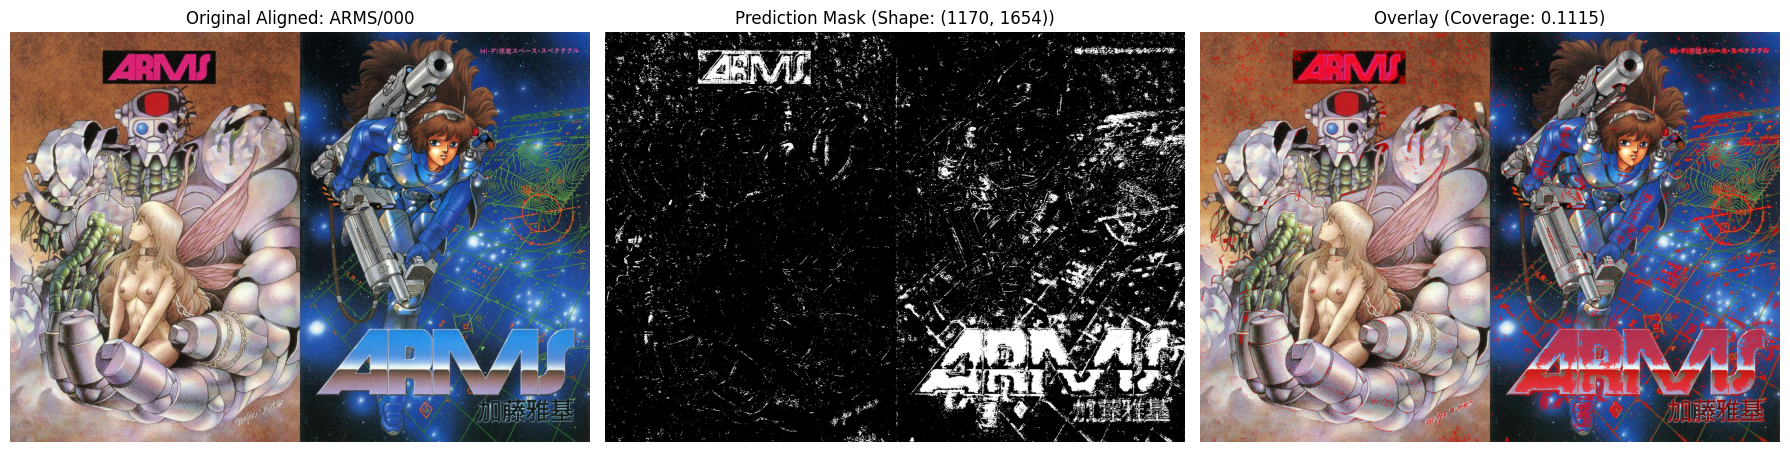

Đường dẫn file mask: /content/deliverables/UNetPP_EfficientNetV2/masks/ARMS/000.png
Các giá trị pixel trong mask: [  0 255]


In [21]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Chọn 1 mẫu bất kỳ từ danh sách đã chạy thành công
sample = manifest[0]
image_id = sample["image_id"]
manga, page_id = image_id.split("/")

# Đọc ảnh gốc và mask tương ứng từ thư mục deliverables
sample_rec = next(r for r in page_list if r["image_id"] == image_id)
_, aligned_img = load_and_align(sample_rec["image_path"])

mask_path = DELIVERABLE_ROOT / sample["mask"]
mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

# Tạo ảnh overlay (phủ màu đỏ lên các pixel văn bản dự đoán)
overlay = aligned_img.copy()
overlay[mask == 255] = (0.35 * overlay[mask == 255] + 0.65 * np.array([255, 0, 0], dtype=np.float32)).astype(np.uint8)

# Hiển thị 3 khung hình cạnh nhau
fig, ax = plt.subplots(1, 3, figsize=(18, 7))

ax[0].imshow(aligned_img)
ax[0].set_title(f"Original Aligned: {image_id}")
ax[0].axis("off")

ax[1].imshow(mask, cmap="gray")
ax[1].set_title(f"Prediction Mask (Shape: {mask.shape})")
ax[1].axis("off")

ax[2].imshow(overlay)
ax[2].set_title(f"Overlay (Coverage: {sample['coverage']:.4f})")
ax[2].axis("off")

plt.tight_layout()
plt.show()

# Kiểm tra các giá trị mức xám có trong file mask
print("Đường dẫn file mask:", mask_path)
print("Các giá trị pixel trong mask:", np.unique(mask))

In [22]:
import shutil
import json
from pathlib import Path

# 1. Tạo một thư mục MỚI tinh ngay tại Google Drive với tên của model
# Đường dẫn: /content/drive/MyDrive/UNetPP_EfficientNetV2
DRIVE_DELIVERABLE_PATH = Path("/content/drive/MyDrive") / METHOD_NAME
DRIVE_DELIVERABLE_PATH.mkdir(parents=True, exist_ok=True)

# 2. Đổi tên file .ipynb thành tên model (vd: unetpp_efficientnetv2.ipynb)
model_notebook_name = f"{METHOD_NAME.lower()}.ipynb"
target_notebook_file = DELIVERABLE_ROOT / model_notebook_name

# Lấy file notebook hiện có trên Colab hoặc Drive để đổi tên
found_notebooks = [p for p in Path("/content").glob("*.ipynb") if not p.name.startswith(".")]
if not found_notebooks:
    # Nếu file nằm trên Drive (thư mục chạy ban đầu)
    found_notebooks = list(Path("/content/drive/MyDrive").glob(f"*{METHOD_NAME}*.ipynb"))

if found_notebooks:
    shutil.copy(found_notebooks[0], target_notebook_file)
    print(f"Đã lưu notebook thành: {model_notebook_name}")
else:
    # Trường hợp không tìm thấy file nguồn, tạo file rỗng theo tên model
    target_notebook_file.touch()

# Xóa các file notebook cũ có tên generic (nếu có) để tránh trùng lặp
for old_nb in DELIVERABLE_ROOT.glob("*.ipynb"):
    if old_nb.name != model_notebook_name:
        old_nb.unlink()

# 3. Đồng bộ toàn bộ nội dung từ DELIVERABLE_ROOT sang thư mục mới trên Google Drive
print(f"Đang sao chép toàn bộ sang thư mục mới trên Drive: {DRIVE_DELIVERABLE_PATH} ...")
shutil.copytree(str(DELIVERABLE_ROOT), str(DRIVE_DELIVERABLE_PATH), dirs_exist_ok=True)

# 4. In kiểm tra cấu trúc bên trong folder mới tạo
print(f"\n--- CẤU TRÚC TRONG THƯ MỤC DRIVE: {DRIVE_DELIVERABLE_PATH.name} ---")
for item in sorted(DRIVE_DELIVERABLE_PATH.iterdir()):
    loai = "Folder" if item.is_dir() else "File"
    print(f"[{loai:<6}] {item.name}")

Đã lưu notebook thành: unetpp_efficientnetv2.ipynb
Đang sao chép toàn bộ sang thư mục mới trên Drive: /content/drive/MyDrive/UNetPP_EfficientNetV2 ...

--- CẤU TRÚC TRONG THƯ MỤC DRIVE: UNetPP_EfficientNetV2 ---
[File  ] README.md
[File  ] errors.json
[Folder] masks
[Folder] metadata
[File  ] requirements.txt
[File  ] unetpp_efficientnetv2.ipynb
[Folder] visualizations
